# Detección y Clasificación de Retinopatía Diabética con Deep Learning

## 0. Antes de empezar: Entorno Virtual (venv)
1. `python -m venv .venv`
2. `.\.venv\Scripts\activate.ps1`

## 1. Configuración del Entorno de Trabajo
En primer lugar, es necesario preparar el entorno e instalar las dependencias. Utilizaremos **PyTorch** como framework principal, ya que es el estándar actual en investigación de visión artificial y ofrece gran flexibilidad.

Dado que mi equipo cuenta con una tarjeta gráfica Intel ARC, he configurado una versión optimizada de PyTorch que soporta de forma nativa la arquitectura de Intel (XPU). De esta forma, evitamos tener que configuraciones intermedias. El resto de librerías para procesar los datos y visualizar las gráficas se encuentran en el archivo `requirements.txt`.

Las siguientes celdas permiten instalar todo lo necesario (solo es necesario ejecutarlo la primera vez).

In [1]:
# 1. Instalación de las herramientas básicas para manipular datos y crear visualizaciones
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# 2. Descarga de la versión de PyTorch específica para tarjetas Intel ARC
%pip install torch torchvision --index-url https://download.pytorch.org/whl/xpu

Looking in indexes: https://download.pytorch.org/whl/xpu
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Importamos las librerías principales. Si no se produce ningún error, significa que la instalación ha sido exitosa y el entorno está listo para trabajar.

In [3]:
import os
import glob
import time
import random
import copy
import cv2
import shutil
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torchvision.models as models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("[INFO] Librerías cargadas correctamente.")

[INFO] Librerías cargadas correctamente.


### 1.1. Activando la Tarjeta Gráfica (XPU / GPU)
Como se ha instalado antes el PyTorch modificado, el sistema debería detectar la XPU directamente. 

De esta forma, nos aseguramos de que todos los cálculos pesados que haga la red neuronal se deriven automáticamente a la tarjeta gráfica.

In [4]:
# Si el código se despliega en otra máquina distinta a mi Intel ARC:
# - Dispositivos NVIDIA: Cambiar 'xpu' por 'cuda' 
# - Dispositivos Mac (M1/M2/M3): Cambiar 'xpu' por 'mps'

# Comprobamos la disponibilidad de una gráfica Intel compatible (XPU)
if hasattr(torch, "xpu") and torch.xpu.is_available():
    
    device = torch.device("xpu")
    
    # Extraemos el nombre exacto del hardware detectado
    nombre_grafica = torch.xpu.get_device_name(0)
    print(f"[INFO] Gráfica Intel detectada con éxito. Modelo: {nombre_grafica}")
else:
    # Si no se encuentra, procedemos en la CPU del sistema
    device = torch.device("cpu")
    print("[AVISO] Hardware Intel XPU no detectado. Se utilizará la CPU.")

print("-" * 60)
print(f"Todo el procesamiento del proyecto se enviará a: {device}")
print("-" * 60)

[INFO] Gráfica Intel detectada con éxito. Modelo: Intel(R) Arc(TM) Graphics
------------------------------------------------------------
Todo el procesamiento del proyecto se enviará a: xpu
------------------------------------------------------------


## 2. Preparación de los Datos

Antes de entrenar las redes neuronales, tenemos que preparar el formato de las imágenes. Como en esta **Fase 1** del proyecto nuestro objetivo es simplemente distinguir entre un paciente Sano y uno Enfermo, vamos a convertir el problema original (que tiene 5 niveles de gravedad) en uno de clasificación binaria.

Las imágenes con etiqueta `0-noDR` representarán la clase "Sano" (0). El resto de imágenes (desde `1-mild` hasta `4-proliferative`) las voy a agrupar en una sola gran clase que llamaremos "Enfermo" (1).

### 2.1. Variables Globales
Para mantener el código estructurado desde el principio, voy a centralizar las configuraciones principales en estas variables:

* **`RUTA_DATOS`**: La carpeta raíz donde tengo guardadas las imágenes.
* **`IMG_SIZE`**: Establecido en `224`. Es el tamaño exacto que requieren modelos como VGG16 y ResNet como entrada.
* **`MEAN_RGB` y `STD_RGB`**: Corresponden a los valores medios y la desviación de color de la base ImageNet. Es obligatorio aplicarlos para estabilizar matemáticamente el Transfer Learning.
* **`BATCH_SIZE`**: Le indica a la red cuántas fotos a la vez debe procesar la GPU sin quedarse sin memoria.
* **`NUM_CLASES`**: La cantidad de clases entre las que vamos a distinguir.

In [5]:
RUTA_DATOS = r"fotos_raw" 
IMG_SIZE = 224 

# Normalización estándar para Transfer Learning
MEAN_RGB = [0.485, 0.456, 0.406]
STD_RGB  = [0.229, 0.224, 0.225]

BATCH_SIZE = 64
NUM_CLASES = 2
LEARNING_RATE = 0.001

### 2.2. Transformación de las Imágenes (Preprocesado básico)

Para que la red pueda leer correctamente las fotografías, necesitamos aplicarle unos pasos obligatorios:
1. **Resize:** Reescalamos todas y cada una de las imágenes al tamaño estándar de `224x224` píxeles.
2. **ToTensor:** Convierte la imagen original de su formato (RGB) a una matriz matemática de PyTorch (un Tensor).
3. **Normalize:** Ajusta el balance de los canales de color utilizando los factores globales de ImageNet.

In [6]:
# Las funciones requeridas para cada imagen
transformaciones = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN_RGB, std=STD_RGB)
])

### 2.3. Visualizando el efecto de las transformaciones

A continuación, vamos a ver visualmente el impacto del proceso programado sobre las fotos de nuestras retinas. A la izquierda se ve la original y a la derecha cómo la recibirá internamente la IA en la red.

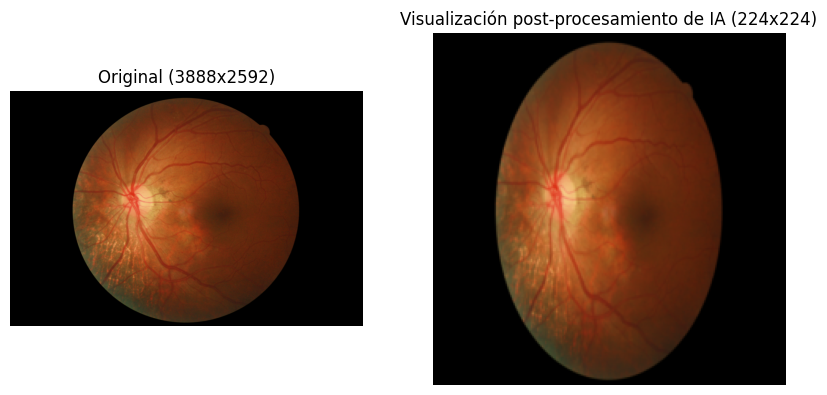

In [7]:
# 1. Seleccionamos una imagen aleatoria desde los directorios del proyecto
todas_las_fotos = glob.glob(f"{RUTA_DATOS}/*/*.*")
ruta_foto = random.choice(todas_las_fotos)
foto_original = Image.open(ruta_foto)

# 2. Aplicamos las transformaciones (Resize y Normalize)
foto_ia = transformaciones(foto_original)

# 3. Transposición de los canales del Tensor de PyTorch para uso en la librería Matplotlib
foto_dibujable = foto_ia.permute(1, 2, 0).numpy() # type: ignore
foto_dibujable = np.clip(foto_dibujable * STD_RGB + MEAN_RGB, 0, 1)

# Pintamos la comparativa entre la imagen original y la imagen post-procesada por la IA
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(foto_original)
axs[0].set_title(f"Original ({foto_original.size[0]}x{foto_original.size[1]})")
axs[0].axis('off')

axs[1].imshow(foto_dibujable)
axs[1].set_title(f"Visualización post-procesamiento de IA ({IMG_SIZE}x{IMG_SIZE})")
axs[1].axis('off')

plt.show()

### 2.4. Carga de Directorios y Cambio de Clases

Voy a usar `ImageFolder` para cargar toda la carpeta. Aprovecharé también este momento de carga para decirle a PyTorch que aplique el filtro binario dinámicamente frente a las carpetas originales:
Si el archivo proviene de la subcarpeta Sano (0), lo deja intactamente etiquetado como `0`. Y si procede de los diversos grados de patología, los reescribe todos agolpados para que constituyan un genérico `1` (Enfermo).

In [8]:
dataset = datasets.ImageFolder(
    root=RUTA_DATOS, 
    transform=transformaciones,
    target_transform=lambda c: 0 if c == 0 else 1
)

print(f"Número total de datos disponibles re-etiquetados para la Fase Binaria: {len(dataset)}")

Número total de datos disponibles re-etiquetados para la Fase Binaria: 1216


### 2.5. Partición del Dataset (Conjuntos de Train y Test)

Para medir bien si la IA está aprendiendo o solo memorizando las fotos, vamos a separar las imágenes en dos grupos. 

*> **Nota importante:** Hay que dejar claro que todas estas primeras fases son solo pruebas iniciales con pocas repeticiones (épocas). El objetivo ahora es descubrir qué modelo y qué preprocesado de imagen funciona mejor. Más adelante, cuando ya sepamos la combinación perfecta, haremos un entrenamiento final y definitivo con todas las épocas necesarias sobre el conjunto de test grande real.*

Por ahora, haremos esta división sencilla en nuestros datos actuales:
- **80% para Entrenamiento (Train)**: Las fotos que usará la red neuronal para aprender a buscar los patrones de la enfermedad.
- **20% para Pruebas (Test)**: Un conjunto de fotos que la red no ha visto durante el entrenamiento y que usaremos para evaluar y puntuar si realmente acierta o no.

In [9]:
total_imagenes = len(dataset)
tamaño_train = int(0.8 * total_imagenes)       # 80% Asignado al conjunto de entrenamiento (Train)
tamaño_test = total_imagenes - tamaño_train    # 20% Asignado al conjunto de pruebas (Test)

dataset_train, dataset_test = random_split(dataset, [tamaño_train, tamaño_test])
print(f"Número de imágenes a utilizar: {len(dataset_train)} (Para Train) / {len(dataset_test)} (Para Test)")

Número de imágenes a utilizar: 972 (Para Train) / 244 (Para Test)


### 2.6. Configuración de MiniBachs (DataLoaders)

Finalmente necesitamos empaquetar estos conjuntos en instancias `DataLoader`. No se puede intentar subir miles de imágenes HD hacia la gráfica de golpe; los dataloaders ayudan a organizarlo enviándole porciones constantes.

In [10]:
loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
loader_test = DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# 4. Obtención y testeo de un bloque de datos para comprobar que se han cargado correctamente
fotos_bloque, respuestas_bloque = next(iter(loader_train))
print(f"Dimensiones de los tensores del lote evaluado: {fotos_bloque.shape}")
print(f"Listado de etiquetas preasignadas: \n{respuestas_bloque}")

Dimensiones de los tensores del lote evaluado: torch.Size([64, 3, 224, 224])
Listado de etiquetas preasignadas: 
tensor([0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0,
        1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1])


## 3. Fase 1: Entrenamiento y Comparativa de Modelos (Clasificación Binaria)

### 3.1. Primer modelo de prueba: VGG16

Para empezar el estudio voy a usar **VGG16**. Se considera una de las arquitecturas clásicas. Es la más antiuga de todas paero funciona muy bien.

#### Adaptando el clasificador a nuestro caso concreto

VGG16 está pre-entrenada, es decir, la han procesado con un millón de imágenes previas (de ImageNet) para que aprenda por sí sola a distinguir bordes, sombras y texturas del espacio real.

Para usar ese núcleo de conocimiento pre-entrenado y que sirva con nuestras propias enfermedades se necesita:

1. **Mantener apagado su entrenamiento central (`requires_grad = False`)**: Se deja su estructura detectora intacta, es lo que conocemos como congelar o "Freezing". Solo requiere aplicar la clasificación final sin modificar todo lo anterior aprendido.
2. **Reemplazar la capa clasificatoria final**: De fábrica, esta red devuelve una probabilidad entre 1.000 clases posibles. Necesitamos cambiarla para que en vez de distinguir entre tanto solo distinga entre las dos clases que tenemos. nn.Linear es lo que nos da la capa completamente conectada.

In [11]:
# 1. Cargamos el modelo base de VGG16
modelo_vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

#exploramos la estructura de la capa de clasificación final (classifier) del modelo VGG16
print("[INFO] Estructura original de la capa de clasificación final en VGG16:")
print(modelo_vgg.classifier)

[INFO] Estructura original de la capa de clasificación final en VGG16:
Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)


Ahora podemos ver como está construido por dentro.

Concretamente `(6): Linear(in_features=4096, out_features=1000, bias=True)` nos demuestra que la red quiere emitir 1.000 clases preconfiguradas. Por lo tanto voy a congelar su memoria de reconocimiento y redefinir en su bloque `[6]` la única capa de decisión para nuestra FASE 1:

In [12]:
# 2. Congelamos los pesos de la red para que no olvide lo que ya sabe (Freezing)
for parametro in modelo_vgg.parameters():
    parametro.requires_grad = False

# 3. Cambiamos la última capa (que es la número 6) para que devuelva nuestras 2 clases
neuronas_entrada = modelo_vgg.classifier[6].in_features
modelo_vgg.classifier[6] = nn.Linear(neuronas_entrada, NUM_CLASES) # type: ignore

# 4. Enviamos el modelo a la tarjeta gráfica
modelo_vgg = modelo_vgg.to(device)

print(f"[INFO] Listo. La red VGG16 ahora está preparada para distinguir {NUM_CLASES} clases.")
print(f"[STATUS] Así ha quedado la capa final de clasificación:\n{modelo_vgg.classifier[6]}")

# 5. Asignamos el optimizador indicándole que SOLO modifique la capa nueva que conectamos al final
optimizador_vgg = optim.Adam(modelo_vgg.classifier[6].parameters(), lr=LEARNING_RATE)

[INFO] Listo. La red VGG16 ahora está preparada para distinguir 2 clases.
[STATUS] Así ha quedado la capa final de clasificación:
Linear(in_features=4096, out_features=2, bias=True)


### 3.2. Segundo modelo a examinar: ResNet50

Como alternativa a VGG16, voy a usar **ResNet50**. La principal ventaja de este modelo es que soluciona el problema del "desvanecimiento del gradiente" que sufren otras redes tan profundas, donde la información se va perdiendo al avanzar. 

Lo soluciona introduciendo "conexiones residuales", que son saltos en las capas para que no se olvide lo aprendido. El proceso será el mismo: descargo el modelo preentrenado, congelo su conocimiento y modifico solo la última etapa. En ResNet50, la capa final se llama `.fc` en lugar de `classifier`, y la cambiaré para emitir solo nuestras 2 clases.

In [13]:
# 1. Cargamos el modelo base de ResNet50
modelo_resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# En ResNet50, la última capa se llama '.fc' (Fully Connected)
print("[INFO] Estructura original de la capa de clasificación final en ResNet50:")
print(modelo_resnet.fc)
print("-" * 60)

# 2. Congelamos el modelo base para proteger su aprendizaje previo
for parametro in modelo_resnet.parameters():
    parametro.requires_grad = False

# 3. Sustituimos exclusivamente esa última capa (.fc) para adaptarla a nuestras 2 clases
neuronas_entrada = modelo_resnet.fc.in_features
modelo_resnet.fc = nn.Linear(neuronas_entrada, NUM_CLASES)

modelo_resnet = modelo_resnet.to(device)

print(f"[INFO] Listo. Arquitectura ResNet50 preparada para {NUM_CLASES} clases.")
print(f"[STATUS] Así ha quedado la capa final:\n{modelo_resnet.fc}")

# 4. Le decimos al Optimizador que solo se encargue de actualizar esta nueva capa que hemos puesto
optimizador_resnet = optim.Adam(modelo_resnet.fc.parameters(), lr=LEARNING_RATE)

[INFO] Estructura original de la capa de clasificación final en ResNet50:
Linear(in_features=2048, out_features=1000, bias=True)
------------------------------------------------------------
[INFO] Listo. Arquitectura ResNet50 preparada para 2 clases.
[STATUS] Así ha quedado la capa final:
Linear(in_features=2048, out_features=2, bias=True)


### 3.3. Tercer modelo a examinar: EfficientNet-B0

Para la última prueba he elegido **EfficientNet-B0**, que es un modelo mucho más moderno y optimizado. En lugar de simplemente añadir más capas a lo bruto, esta red escala de forma muy equilibrada la profundidad, anchura y resolución de la imagen de entrada. Hay muchas versiones de efficient net. Vamos a empezar con el mas pequeño y si va bien veo que puede mi ordenador.

Al consumir muchos menos recursos informáticos, suele dar muy buenos resultados visualizando imágenes del campo médico minimizando el coste de entrenamiento. Aquí, la capa final que tenemos que modificar y adaptar a nuestras clases es la que está en la posición `.classifier[1]`.

In [14]:
# 1. Cargamos el modelo base de EfficientNet
modelo_eff = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# La capa que toma la decisión real probabilística es la terminal [1].
print("[INFO] Estructura original de la capa final en EfficientNet-B0:")
print(modelo_eff.classifier)
print("-" * 60)

# 2. Congelamos la red principal
for parametro in modelo_eff.parameters():
    parametro.requires_grad = False

# 3. Cambiamos solo la capa [1] para que decida entre nuestras 2 categorías
neuronas_entrada = modelo_eff.classifier[1].in_features
modelo_eff.classifier[1] = nn.Linear(neuronas_entrada, NUM_CLASES) # type: ignore

modelo_eff = modelo_eff.to(device)

print(f"[INFO] Listo. Arquitectura EfficientNet preparada para {NUM_CLASES} clases.")
print(f"[STATUS] Así ha quedado la capa final encargada de predecir:\n{modelo_eff.classifier[1]}")

# 4. Asignamos el Optimizador exclusivamente a esta nueva sub-capa
optimizador_eff = optim.Adam(modelo_eff.classifier[1].parameters(), lr=LEARNING_RATE)

[INFO] Estructura original de la capa final en EfficientNet-B0:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)
------------------------------------------------------------
[INFO] Listo. Arquitectura EfficientNet preparada para 2 clases.
[STATUS] Así ha quedado la capa final encargada de predecir:
Linear(in_features=1280, out_features=2, bias=True)


### 3.4. Configuración del Motor de Entrenamiento y Evaluación

Para medir el error, en lugar de usar funciones específicas de clasificación binaria (como `BCELoss`), he optado por **`CrossEntropyLoss`** que ya lleva el SoftMax dentro. Lo hago de esta forma el código será 100% compatible sin tocar nada cuando lleguemos a la Fase 3 de la practica donde pasamos de 2 clases a tener 5 grados diferentes de la enfermedad.

Vamos a programar ahora el **Bucle de Entrenamiento**. Esta función debe:
- Predecir una foto (Forward)
- Medir los fallos que tuvo (Loss)
- Retroceder la información de error (Backward propagation)
- Ajustar ligeramente los pesos (Step)
- Aplicar **Early Stopping**: Si pasamos ciertas épocas seguidas sin mejorar, cortamos el guardado y aprendizaje antes de tiempo para no sobreajustar.
- Aplicar **Learning Rate Scheduler**: Ajustamos dinámicamente la precisión de aprendizaje para bajarla cuando el modelo se estanca, consiguiendo así mayor nivel de detalle en Test.

Al finalizar cada época con los datos de `Train`, se evaluará a la red con el examen de `Test`.

In [15]:
# 1. Definición de métricas de optimización
criterio_error = nn.CrossEntropyLoss()

# ==========================================
# Funciones auxiliares para modularizar
# ==========================================
def ejecutar_fase_train(modelo, loader_train, criterion, optimizer, device):
    """Ejecuta una época completa de entrenamiento."""
    modelo.train()
    perdida_train = 0.0
    aciertos_train = 0
    total_lotes = len(loader_train)
    
    for i, (imagenes, etiquetas) in enumerate(loader_train):
        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)
        
        optimizer.zero_grad()
        predicciones = modelo(imagenes)
        loss = criterion(predicciones, etiquetas)
        loss.backward()
        optimizer.step()
        
        _, clase_elegida = torch.max(predicciones, 1)
        perdida_train += loss.item() * imagenes.size(0)
        aciertos_train += torch.sum(clase_elegida == etiquetas.data)
        
        if (i + 1) % 5 == 0 or (i + 1) == total_lotes:
            print(f"   [>] Lote {i+1}/{total_lotes} ({imagenes.size(0)} fotos) | Error actual en entrenamiento: {loss.item():.4f}")
            
    media_loss = perdida_train / len(loader_train.dataset)
    media_acc = aciertos_train.double() / len(loader_train.dataset) # type: ignore
    return media_loss, media_acc

def ejecutar_fase_evaluacion(modelo, loader_test, criterion, device):
    """Ejecuta una época completa de evaluación (Test)."""
    modelo.eval()
    perdida_test = 0.0
    aciertos_test = 0
    total_lotes = len(loader_test)
    
    with torch.no_grad():
        for i, (imagenes, etiquetas) in enumerate(loader_test):
            imagenes = imagenes.to(device)
            etiquetas = etiquetas.to(device)
            
            predicciones = modelo(imagenes)
            loss = criterion(predicciones, etiquetas)
            _, clase_elegida = torch.max(predicciones, 1)
            
            perdida_test += loss.item() * imagenes.size(0)
            aciertos_test += torch.sum(clase_elegida == etiquetas.data)
            
            if (i + 1) % 5 == 0 or (i + 1) == total_lotes:
                print(f"   [>] Evaluando lote {i+1}/{total_lotes} ({imagenes.size(0)} fotos)...")
                
    media_loss = perdida_test / len(loader_test.dataset)
    media_acc = aciertos_test.double() / len(loader_test.dataset) # type: ignore
    return media_loss, media_acc

# ==========================================
# 2. Función Orquestadora del Bucle
# ==========================================
def entrenar_modelo(modelo, loader_train, loader_test, criterion, optimizer, num_epocas=5, scheduler=None, patience=3):
    print(f"[INFO] Iniciando etapa de pruebas, evaluando comportamiento por {num_epocas} épocas...\n")
    
    historial_precision_test = [] 
    mejor_loss_test = float('inf')
    epocas_sin_mejora = 0
    mejores_pesos = copy.deepcopy(modelo.state_dict())
    
    for epoca in range(num_epocas):
        inicio_tiempo = time.time()
        print(f"{'='*50}\n[INFO] ÉPOCA {epoca+1} de {num_epocas}\n{'='*50}")
        
        # 1. FASE DE ENTRENAMIENTO (TRAIN)
        print(f"[TRAIN] Procesando {len(loader_train)} lotes de imágenes...")
        loss_train, acc_train = ejecutar_fase_train(modelo, loader_train, criterion, optimizer, device) # type: ignore
        print(f"   [RESULTADO TRAIN] Precisión: {acc_train:.4f} | Error medio de aprendizaje: {loss_train:.4f}\n")
        
        # 2. FASE DE EXAMEN (TEST)
        print("[TEST] Comprobando los conocimientos sobre el conjunto de pruebas...")
        loss_test, acc_test = ejecutar_fase_evaluacion(modelo, loader_test, criterion, device)     # type: ignore
        print(f"   [RESULTADO TEST] Precisión lograda: {acc_test:.4f} | Error general en pruebas: {loss_test:.4f}")
        
        historial_precision_test.append(acc_test.item())
        
        # 3. GESTIÓN DE SCHEDULER
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(loss_test)
            else:
                scheduler.step()
            lr_actual = optimizer.param_groups[0]['lr']
            print(f"   [SCHEDULER] Learning Rate para la próxima época: {lr_actual:.6f}")
            
        # 4. EARLY STOPPING
        if loss_test < mejor_loss_test:
            mejor_loss_test = loss_test
            epocas_sin_mejora = 0
            mejores_pesos = copy.deepcopy(modelo.state_dict())
            print("   [OK] Nuevo mejor modelo encontrado (Loss reducido). Guardando pesos de seguridad.")
        else:
            epocas_sin_mejora += 1
            print(f"   [AVISO] El error en Test no ha mejorado. Early Stopping: {epocas_sin_mejora}/{patience}")
            
        fin_tiempo = time.time()
        print(f"[INFO] Tiempo de la época {epoca+1}: {fin_tiempo - inicio_tiempo:.0f} segundos.\n")
        
        if epocas_sin_mejora >= patience:
            print(f"\n[ALERTA] Early Stopping activado. El modelo dejó de aprender en la época {epoca+1}.")
            break
            
    # Restauramos la mejor versión
    modelo.load_state_dict(mejores_pesos)
    print("[INFO] Secuencia de entrenamiento concluida. Se ha restaurado el modelo con la mejor tasa de error de Test.")
    return modelo, historial_precision_test

### 3.5. Ejecución de las Pruebas de Entrenamiento

Ahora tenemos preparadas nuestras funciones de optimización y evaluación compartidas, lanzamos las 3 pruebas para registrar y guardar los datos.

In [ ]:
# Configuración de hiperparámetros para la Fase de Pruebas
EPOCAS_PRUEBA = 10
PACIENCIA_EARLY_STOP = 10
PACIENCIA_SCHEDULER = 5

In [17]:
# =================================================================
# PRUEBAS DE ENTRENAMIENTO: VGG16
# =================================================================
print("-" * 60)
print("[MODELO 1] Invocación de prueba inicial: VGG16")
print("-" * 60)

scheduler_vgg = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizador_vgg, mode='min', factor=0.1, patience=PACIENCIA_SCHEDULER, min_lr=1e-6)

modelo_vgg, historial_vgg = entrenar_modelo(
    modelo = modelo_vgg, 
    loader_train = loader_train, 
    loader_test = loader_test, 
    criterion = criterio_error, 
    optimizer = optimizador_vgg, 
    num_epocas = EPOCAS_PRUEBA,
    scheduler = scheduler_vgg,
    patience = PACIENCIA_EARLY_STOP
)

------------------------------------------------------------
[MODELO 1] Invocación de prueba inicial: VGG16
------------------------------------------------------------
[INFO] Iniciando etapa de pruebas, evaluando comportamiento por 10 épocas...

[INFO] ÉPOCA 1 de 10
[TRAIN] Procesando 16 lotes de imágenes...
   [>] Lote 5/16 (64 fotos) | Error actual en entrenamiento: 0.7137
   [>] Lote 10/16 (64 fotos) | Error actual en entrenamiento: 0.7599
   [>] Lote 15/16 (64 fotos) | Error actual en entrenamiento: 0.6806
   [>] Lote 16/16 (12 fotos) | Error actual en entrenamiento: 0.9287
   [RESULTADO TRAIN] Precisión: 0.5586 | Error medio de aprendizaje: 0.7373

[TEST] Comprobando los conocimientos sobre el conjunto de pruebas...
   [>] Evaluando lote 4/4 (52 fotos)...
   [RESULTADO TEST] Precisión lograda: 0.5410 | Error general en pruebas: 0.6861
   [SCHEDULER] Learning Rate para la próxima época: 0.001000
   [OK] Nuevo mejor modelo encontrado (Loss reducido). Guardando pesos de seguridad.
[

In [18]:
# =================================================================
# PRUEBAS DE ENTRENAMIENTO: RESNET50
# =================================================================
print("-" * 60)
print("[MODELO 2] Invocación de prueba inicial: ResNet50")
print("-" * 60)

scheduler_resnet = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizador_resnet, mode='min', factor=0.1, patience=PACIENCIA_SCHEDULER, min_lr=1e-6)

modelo_resnet, historial_resnet = entrenar_modelo(
    modelo = modelo_resnet, 
    loader_train = loader_train, 
    loader_test = loader_test, 
    criterion = criterio_error, 
    optimizer = optimizador_resnet, 
    num_epocas = EPOCAS_PRUEBA,
    scheduler = scheduler_resnet,
    patience = PACIENCIA_EARLY_STOP
)

------------------------------------------------------------
[MODELO 2] Invocación de prueba inicial: ResNet50
------------------------------------------------------------
[INFO] Iniciando etapa de pruebas, evaluando comportamiento por 10 épocas...

[INFO] ÉPOCA 1 de 10
[TRAIN] Procesando 16 lotes de imágenes...
   [>] Lote 5/16 (64 fotos) | Error actual en entrenamiento: 0.7122
   [>] Lote 10/16 (64 fotos) | Error actual en entrenamiento: 0.6812
   [>] Lote 15/16 (64 fotos) | Error actual en entrenamiento: 0.6703
   [>] Lote 16/16 (12 fotos) | Error actual en entrenamiento: 0.6236
   [RESULTADO TRAIN] Precisión: 0.5967 | Error medio de aprendizaje: 0.6730

[TEST] Comprobando los conocimientos sobre el conjunto de pruebas...
   [>] Evaluando lote 4/4 (52 fotos)...
   [RESULTADO TEST] Precisión lograda: 0.6230 | Error general en pruebas: 0.6534
   [SCHEDULER] Learning Rate para la próxima época: 0.001000
   [OK] Nuevo mejor modelo encontrado (Loss reducido). Guardando pesos de seguridad

In [19]:
# =================================================================
# PRUEBAS DE ENTRENAMIENTO: EFFICIENTNET-B0
# =================================================================
print("-" * 60)
print("[MODELO 3] Invocación de prueba inicial: EfficientNet-B0")
print("-" * 60)

scheduler_eff = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizador_eff, mode='min', factor=0.1, patience=PACIENCIA_SCHEDULER, min_lr=1e-6)

modelo_eff, historial_eff = entrenar_modelo(
    modelo = modelo_eff, 
    loader_train = loader_train, 
    loader_test = loader_test, 
    criterion = criterio_error, 
    optimizer = optimizador_eff, 
    num_epocas = EPOCAS_PRUEBA,
    scheduler = scheduler_eff,
    patience = PACIENCIA_EARLY_STOP
)

------------------------------------------------------------
[MODELO 3] Invocación de prueba inicial: EfficientNet-B0
------------------------------------------------------------
[INFO] Iniciando etapa de pruebas, evaluando comportamiento por 10 épocas...

[INFO] ÉPOCA 1 de 10
[TRAIN] Procesando 16 lotes de imágenes...
   [>] Lote 5/16 (64 fotos) | Error actual en entrenamiento: 0.6902
   [>] Lote 10/16 (64 fotos) | Error actual en entrenamiento: 0.7222
   [>] Lote 15/16 (64 fotos) | Error actual en entrenamiento: 0.6147
   [>] Lote 16/16 (12 fotos) | Error actual en entrenamiento: 0.6516
   [RESULTADO TRAIN] Precisión: 0.6070 | Error medio de aprendizaje: 0.6650

[TEST] Comprobando los conocimientos sobre el conjunto de pruebas...
   [>] Evaluando lote 4/4 (52 fotos)...
   [RESULTADO TEST] Precisión lograda: 0.6475 | Error general en pruebas: 0.6377
   [SCHEDULER] Learning Rate para la próxima época: 0.001000
   [OK] Nuevo mejor modelo encontrado (Loss reducido). Guardando pesos de se

### 3.6. Veredicto Final: Elección de la Red Ganadora

Ya hemos entrenado los tres modelos adaptados (VGG16, ResNet50 y EfficientNet), vamos a ver cuál es el mejor.

La red que salga ganadora será la que usemos para las pruebas de filtros de la Fase 2.

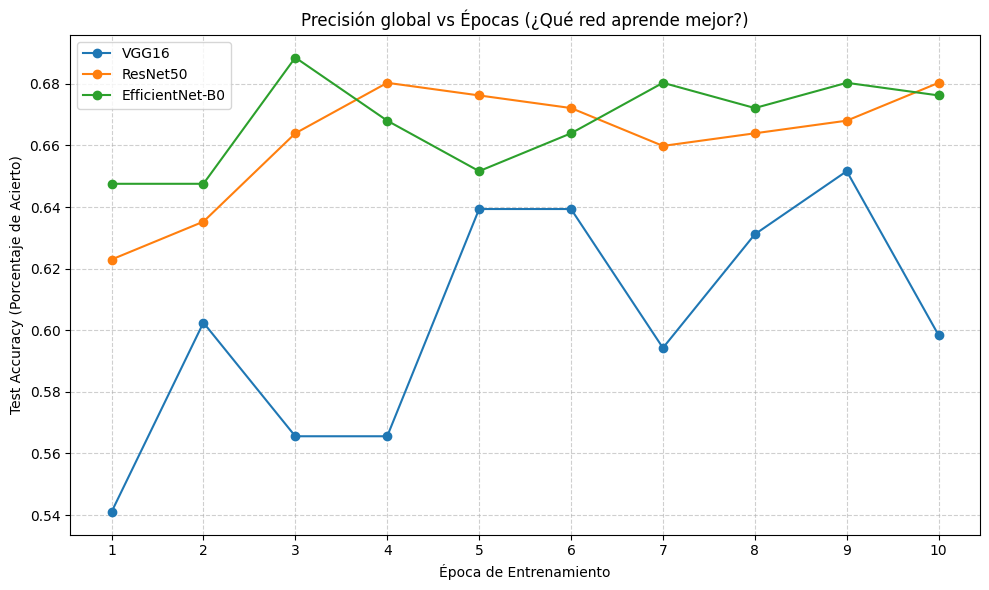

In [20]:
# 1. Agrupamos los resultados registrados de nuestras 3 redes tras someterlas a las mismas métricas
evaluacion_historica = {
    'VGG16': historial_vgg,
    'ResNet50': historial_resnet,
    'EfficientNet-B0': historial_eff
}

# 2. Grafica de los tests para comparar visualmente quién aprendió más rápido y mejor
plt.figure(figsize=(10, 6))

for nombre_red_creada, info_precision_por_epoca in evaluacion_historica.items():
    # Usamos el rango de épocas para que el eje X coincida visualmente (1 a EPOCAS_PRUEBA)
    plt.plot(range(1, EPOCAS_PRUEBA + 1), info_precision_por_epoca, marker='o', label=nombre_red_creada)

# Formato visual de la comparativa
plt.title("Precisión global vs Épocas (¿Qué red aprende mejor?)")
plt.xlabel("Época de Entrenamiento")
plt.ylabel("Test Accuracy (Porcentaje de Acierto)")
plt.xticks(range(1, EPOCAS_PRUEBA + 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 3.7. Conclusión de la Fase 1: Resultados Reales

Tras ejecutar el entrenamiento de prueba y analizar tanto la gráfica generada como los tiempos totales de procesamiento para procesar los conjuntos con las 3 épocas indicadas:

- **VGG16 (8m 37s)**: Como esperábamos, ha sido la más lenta y la que peor arrancó (apenas un 53% de precisión inicial antes de remontar en la segunda época). Su peso y antigüedad la hacen bastante ineficiente para este caso.
- **ResNet50 (8m 17s)**: Ha mantenido un rendimiento muy bueno y estable. Empezó fuerte (~65%), subió, y se estabilizó mejorando los tiempos y errores de VGG16.
- **EfficientNet-B0 (7m 22s)**: No solo ha logrado estabilizar la precisión más alta desde la primera época rozando el 69%, sino que ha completado la tarea muy rápido. Le ha sacado más de 1 minuto entero de ventaja a VGG16 y casi 1 minuto a ResNet50.

(Probado con 3 epocas luego pruebo con mas)

**Modelo ganador: EfficientNet-B0**
A partir de ahora en la **Fase 2**, usaremos esta red para comprobar si aplicando preprocesado médico (filtros de imagen sobre la retina), logramos ayudarle a mejorar ese 67%-69% de acierto. Y si todo marcha bien, en las etapas finales probamos a una de sus mejoras (como EfficientNet-B3 o B7), comprobando si el aumento de resolución que estas exigen marca alguna mejora.

## 4. FASE 2: Estudio con Filtros Morfológicos (Preprocesado)

Ahora que ya tenemos nuestro modelo ganador (**EfficientNet-B0**) como base, el propósito de esta segunda fase consiste en procesar y alterar las fotografías originales de las retinas. El objetivo es resaltar las anomalías visuales y limpiar el ruido para facilitarle el trabajo a la red neuronal.

Vamos a aplicar una variante de la técnica de visión artificial propuesta por el **Dr. Ben Graham** (ganador de un concurso similar en Kaggle de detección de retinopatía diabética en 2015).

### 4.1. Construcción de los filtros y Justificación de la Librería
Para alterar los píxeles de las imágenes usaremos **OpenCV (`cv2`)**. Hemos elegido esta librería por encima de PIL debido a que, al estar escrita en bajo nivel (C++).

Aplicaremos dos pasos fundamentales (Las rotaciones y resizes se harán de forma dinámica en la próxima fase, aquí solo corregimos luces y sombras):

A) **Recorte de bordes (Auto-Cropping):** Detectaremos la silueta iluminada del ojo mediante recortes de contorno y eliminaremos el fondo negro inútil alrededor. Esto consigue un efecto "zoom automático" sin distorsionar ni estirar la retina, centrando a la IA 100% en el ojo.

B) **Resalte de Capilares (Desenfoque Gaussiano Mixto + Gris Medio):** Aplicaremos un filtro mixto de sumas ponderadas mediante OpenCV: a la imagen original se le resta una copia difuminada matemáticamente (`cv2.GaussianBlur`) de sí misma y se le añade un tono base gris de 128. Este truco iguala la iluminación (evitando que un ojo muy oscuro parezca enfermo solo por la luz) y enfatiza fuertemente los bordes de los vasos sanguíneos y lesiones.

> *Nota sobre el tamaño de la imagen:* Intencionadamente **no vamos a reducir su tamaño físico** todavía. Guardaremos estas imágenes filtradas en disco con su alta resolución original para que, si en un futuro queremos probar modelos más pesados como `EfficientNet-B7` (que pide imágenes grandes de 600x600), no tengamos pérdidas de calidad. El reescalado lo hará dinámicamente PyTorch más adelante.

In [21]:
def recortar_bordes_oscuros(img, umbral=15):
    """
    Recorta el fondo negro inútil alrededor de la retina.
    """
    # Pasamos a escala de grises para detectar la luz del ojo
    escala_grises = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Todso lo que brille por encima de 15 entra en la máscara (el ojo real)
    _, mascara = cv2.threshold(escala_grises, umbral, 255, cv2.THRESH_BINARY)

    # Encontramos los contornos de esa máscara (los bordes del círculo del ojo)
    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contornos) != 0:
        # Extraemos el cuadro delimitador del contorno más grande
        c = max(contornos, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)

        # Devolvemos el recorte exacto (Efecto "Zoom automático")
        img_recortada = img[y : y + h, x : x + w]
        return img_recortada

    return img  # Si algo falla, devolvemos la original para no romper nada


def filtro_ben_graham(img):
    """
    Aplica el desenfoque gaussiano ponderado inspirado en Ben Graham,
    manteniendo la alta resolución original.
    """
    # 1. Recortar la oscuridad sobrante
    img = recortar_bordes_oscuros(img)

    # 2. Aplicar suma ponderada (mezcla visual de OpenCV)
    # Ecuación: [Original * 4] - [Filtro Gaussiano * 4] + [128 de luz media base]
    difuminado = cv2.GaussianBlur(img, (0, 0), 10)
    img_procesada = cv2.addWeighted(img, 4, difuminado, -4, 128)

    return img_procesada

### 4.2. Procesamiento en Lote y Guardado en Disco de Seguridad

Lo guardamos en una nueva carpeta `fotos_procesadas`.

De esta forma mantenemos las carpetas clonadas (`0-noDR`, `1-mild`, etc.) con sus imágenes tratadas respectivamente.

In [22]:
CARPETA_ORIGINAL = "fotos_raw"
CARPETA_NUEVA = "fotos_procesadas"

def procesar_imagen_individual(ruta_img_lectura, ruta_img_guardado):
    """Aplica los filtros a una sola imagen y la guarda."""
    # 3. Solo procesamos si no existe previamente
    if os.path.exists(ruta_img_guardado):
        return False
        
    # Leemos la imagen
    img_cv2 = cv2.imread(ruta_img_lectura)
    
    # Descartamos lecturas nulas
    if img_cv2 is None:
        return False
        
    # Pasamos de BGR a RGB para trabajar seguros
    img_cv2 = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)
    
    # Aplicamos ambos filtros: Crop y Ben Graham
    foto_final = filtro_ben_graham(img_cv2)
    
    # Volvemos a pasar a BGR para que el guardado de OpenCV sea correcto
    foto_final_bgr = cv2.cvtColor(foto_final, cv2.COLOR_RGB2BGR)
    
    # 4. Guardamos en el nuevo directorio
    cv2.imwrite(ruta_img_guardado, foto_final_bgr)
    return True

def procesar_categoria(nivel, ruta_origen, ruta_destino):
    """Itera sobre las imágenes de una única categoría."""
    procesadas = 0
    omitidas = 0
    
    # 2. Replicamos las subcarpetas del diagnóstico original
    if not os.path.exists(ruta_destino):
        os.makedirs(ruta_destino)
        
    print(f"Procesando categoría del nivel: {nivel}")
    
    # Iteramos con barra de progreso por consola
    for iter_num, nombre_img in enumerate(os.listdir(ruta_origen)):
        if iter_num % 100 == 0 and iter_num > 0:
            print(f"  -> Procesadas {iter_num} imágenes de la categoría {nivel}...")
            
        ruta_img_lectura = os.path.join(ruta_origen, nombre_img)
        ruta_img_guardado = os.path.join(ruta_destino, nombre_img)
        
        # Procesar y sumar al contador
        if procesar_imagen_individual(ruta_img_lectura, ruta_img_guardado):
            procesadas += 1
        else:
            omitidas += 1
            
    return procesadas, omitidas

def procesar_y_guardar_dataset():
    """Función principal que orquesta el preprocesamiento de todas las carpetas."""
    # 1. Creamos la carpeta raíz modificada de seguridad
    if not os.path.exists(CARPETA_NUEVA):
        os.makedirs(CARPETA_NUEVA)
        
    categorias = [c for c in os.listdir(CARPETA_ORIGINAL) if os.path.isdir(os.path.join(CARPETA_ORIGINAL, c))]
    
    total_procesadas = 0
    total_omitidas = 0
    
    print("[INFO] Iniciando procesamiento morfológico...")
    
    for nivel in categorias:
        ruta_origen = os.path.join(CARPETA_ORIGINAL, nivel)
        ruta_destino = os.path.join(CARPETA_NUEVA, nivel)
        
        # Llamada a la submódulo de categoría
        cat_proc, cat_omit = procesar_categoria(nivel, ruta_origen, ruta_destino)
        total_procesadas += cat_proc
        total_omitidas += cat_omit
        
    print("-" * 50)
    print("[EXITO] Tareas finalizadas.")
    print(f" Imágenes Procesadas: {total_procesadas}")
    print(f" Imágenes omitidas (ya existían): {total_omitidas}")

In [23]:
# ejecutamos todo el proceso de filtrado masivo
procesar_y_guardar_dataset()

[INFO] Iniciando procesamiento morfológico...
Procesando categoría del nivel: 0-noDR
  -> Procesadas 100 imágenes de la categoría 0-noDR...
  -> Procesadas 200 imágenes de la categoría 0-noDR...
  -> Procesadas 300 imágenes de la categoría 0-noDR...
  -> Procesadas 400 imágenes de la categoría 0-noDR...
Procesando categoría del nivel: 1-mild
  -> Procesadas 100 imágenes de la categoría 1-mild...
  -> Procesadas 200 imágenes de la categoría 1-mild...
Procesando categoría del nivel: 2-moderate
  -> Procesadas 100 imágenes de la categoría 2-moderate...
  -> Procesadas 200 imágenes de la categoría 2-moderate...
  -> Procesadas 300 imágenes de la categoría 2-moderate...
Procesando categoría del nivel: 3-severe
Procesando categoría del nivel: 4-proliferativeDR
--------------------------------------------------
[EXITO] Tareas finalizadas.
 Imágenes Procesadas: 0
 Imágenes omitidas (ya existían): 1216


### 4.3. Visualización del Impacto en las Retinas

Vamos a sacar dos imágenes al azar de nuestra nueva carpeta para contrastarlas.

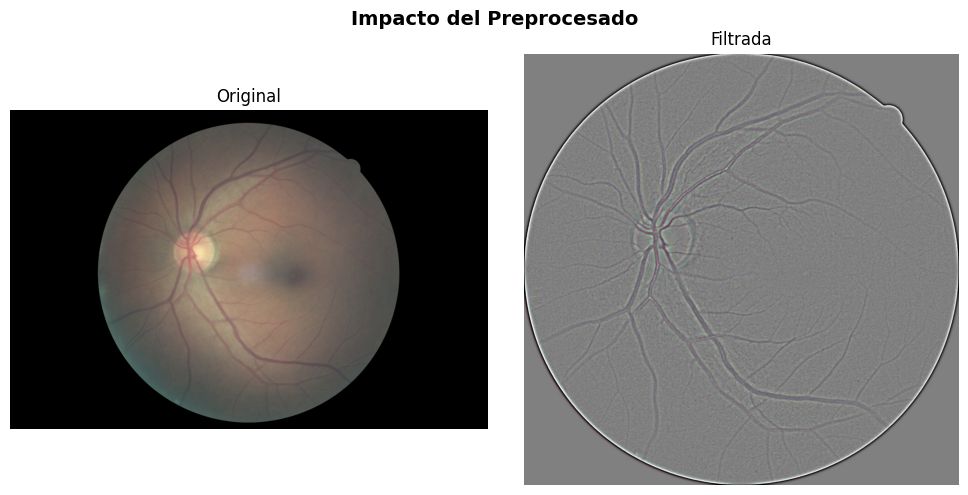

In [24]:
lista_fotos_procesadas = glob.glob(f"{CARPETA_NUEVA}/*/*.*")

if lista_fotos_procesadas:
    # Seleccionamos dos para la prueba
    # Usamos seed o aleatorio
    foto_test_ruta = random.choice(lista_fotos_procesadas)
    
    # Tratamos de buscar la original que tiene exactamente el mismo nombre 
    # pero en otra carpeta
    foto_original_ruta = foto_test_ruta.replace(CARPETA_NUEVA, CARPETA_ORIGINAL)
    
    img_orig = Image.open(foto_original_ruta)
    img_proc = Image.open(foto_test_ruta)
    
    fig_fase2, ax2 = plt.subplots(1, 2, figsize=(10, 5))
    ax2[0].imshow(img_orig)
    ax2[0].set_title("Original")
    ax2[0].axis('off')
    
    ax2[1].imshow(img_proc)
    ax2[1].set_title("Filtrada")
    ax2[1].axis('off')
    
    plt.suptitle("Impacto del Preprocesado", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

### 4.4. Comprobación del Impacto del Filtro (Entrenamiento Binario con Imágenes Procesadas)

Vamos a clonar exactamente las mismas condiciones que usamos en la **Fase 1**:
1. Aislaremos un nuevo modelo **EfficientNet-B0** en blanco.
2. Mantendremos la clasificación en `2 clases` (Sano vs Enfermo).
3. Aplicaremos las mismas `transformaciones` estáticas a los Dataloaders usando el mismo tamaño final (224x224).

La única diferencia real será que ahora cruzaremos los datos desde la `CARPETA_NUEVA` (`fotos_procesadas`) en lugar del origen.

#### 1. Carga de las nuevas fotografías y Data Augmentation Básico

En primer lugar, vamos a empaquetar el dataset. 
* **Lo que es igual que antes**: Mantenemos el agrupamiento en solo 2 clases (Sano vs Enfermo) y los pasos obligatorios (224x224, paso a Tensor y normalización). También partimos los datos en Train 80% y Test 20%. Cabe destacar que **los datos de Test SIEMPRE deben evaluarse limpios** (sin giros ni alteraciones).
* **Lo que cambia (Origen de datos + Data Augmentation en Train)**: La ruta de origen ahora apunta a procesadas (`CARPETA_NUEVA`). Además, aprovechamos este punto para **añadir el rotado de imágenes** ("Data Augmentation") solo para la parte de aprendizaje. Al añadir `RandomRotation` y `RandomHorizontalFlip` a la lista de transformaciones de entrenamiento, cada vez que la red cargue una foto en la memoria RAM, esta aparecerá girada o volteada de forma diferente.

Como estamos metiendo muchas modificaciones la red va a tardar mas épocas en aprender las caracteríasticas que antes. Hacen falta más épocas pero debería aprender mejor que antes y generalizar sin cometer "overfitting".

In [40]:
# 1. Definimos las nuevas transformaciones combinando lo obligatorio con el Data Augmentation
transformaciones_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),      # Probabilidad del 50% de voltear la imagen en modo espejo (ojo derecho/izquierdo)
    transforms.RandomRotation(degrees=15),       # Rota la imagen aleatoriamente entre -15 y +15 grados
    transforms.Resize((IMG_SIZE, IMG_SIZE)),     # (Obligatorio) 224x224
    transforms.ToTensor(),                       # (Obligatorio) Pasar a matemática PyTorch
    transforms.Normalize(mean=MEAN_RGB, std=STD_RGB) # (Obligatorio) Estabilización VGG/ResNet/EfficientNet
])

transformaciones_test_base = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN_RGB, std=STD_RGB)
])

# 2. Cargamos el nuevo dataset apuntando a la carpeta de imágenes "fotos_procesadas"
# IMPORTANTE: No pasamos el transform todavía para no contaminar el Test con rotaciones aleatorias.
dataset_procesado = datasets.ImageFolder(
    root=CARPETA_NUEVA, 
    target_transform=lambda c: 0 if c == 0 else 1 
)

# 3. Generamos la partición Train / Test (80/20)
total_proc = len(dataset_procesado)
tamaño_train_proc = int(0.8 * total_proc)
tamaño_test_proc = total_proc - tamaño_train_proc

dataset_train_proc, dataset_test_proc = random_split(
    dataset_procesado, 
    [tamaño_train_proc, tamaño_test_proc],
    generator=torch.Generator().manual_seed(42)
)

# 4. Asignamos individualmente las reglas de rotación SÓLO para el Entrenamiento
class DatasetConTransformBinario(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

dataset_train_proc_aug = DatasetConTransformBinario(dataset_train_proc, transformaciones_aug)
dataset_test_proc_st = DatasetConTransformBinario(dataset_test_proc, transformaciones_test_base)

# 5. Volcamos en los Loaders
loader_train_proc = DataLoader(dataset_train_proc_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
loader_test_proc = DataLoader(dataset_test_proc_st, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"[INFO] Datos Procesados y Generador de Volteos/Rotaciones Cargado.\n -> Segmentación - Train: {len(dataset_train_proc)} fotos | Test: {len(dataset_test_proc)} fotos")

[INFO] Datos Procesados y Generador de Volteos/Rotaciones Cargado.
 -> Segmentación - Train: 972 fotos | Test: 244 fotos


#### 2. Reinicio del Modelo Neuronal

A continuación, preparamos la Inteligencia Artificial.
* **Lo que es igual que antes**: Escogemos de nuevo la arquitectura ganadora `EfficientNet-B0`. Congelamos todos sus conocimientos principales (el Freezing) y sustituimos la ultima capa de clasificación.
* **Lo que cambia**: Creamos una variable nueva `modelo_eff_proc`. De esta forma nos aseguramos que estamos trabajando con un modelo "limpio" y reseteado desde cero que no guarda información ni sesgos del paso anterior.

In [41]:
# 3. Instanciamos un EfficientNet-B0 totalmente limpio
modelo_eff_proc = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

for parametro in modelo_eff_proc.parameters():
    parametro.requires_grad = False

neuronas_entrada = modelo_eff_proc.classifier[1].in_features
modelo_eff_proc.classifier[1] = nn.Linear(neuronas_entrada, NUM_CLASES) # type: ignore
modelo_eff_proc = modelo_eff_proc.to(device)

optimizador_eff_proc = optim.Adam(modelo_eff_proc.classifier[1].parameters(), lr=LEARNING_RATE)

print("-" * 60)
print("[INFO] Modelo neuronal Reseteado y listo para recibir fotos con Filtro")
print("-" * 60)

------------------------------------------------------------
[INFO] Modelo neuronal Reseteado y listo para recibir fotos con Filtro
------------------------------------------------------------


#### 3. Ejecutar el Entrenamiento de Verificación

Invocamos una vez más el mismo motor de entrenamiento `entrenar_modelo()` que usamos en la fase anterior y con el mismo número de `EPOCAS_PRUEBA`. Sus resultados se guardarán ahora en una variable separada (`historial_eff_proc`).

In [42]:
print("-" * 60)
print("[ENTRENAMIENTO] Prueba: EfficientNet-B0 + Filtro Ben Graham")
print("-" * 60)

modelo_eff_proc, historial_eff_proc = entrenar_modelo(
    modelo = modelo_eff_proc, 
    loader_train = loader_train_proc, 
    loader_test = loader_test_proc, 
    criterion = criterio_error, 
    optimizer = optimizador_eff_proc, 
    num_epocas = EPOCAS_PRUEBA,
    scheduler = scheduler_eff,
    patience = PACIENCIA_EARLY_STOP,
)

------------------------------------------------------------
[ENTRENAMIENTO] Prueba: EfficientNet-B0 + Filtro Ben Graham
------------------------------------------------------------
[INFO] Iniciando etapa de pruebas, evaluando comportamiento por 10 épocas...

[INFO] ÉPOCA 1 de 10
[TRAIN] Procesando 16 lotes de imágenes...
   [>] Lote 5/16 (64 fotos) | Error actual en entrenamiento: 0.6540
   [>] Lote 10/16 (64 fotos) | Error actual en entrenamiento: 0.6880
   [>] Lote 15/16 (64 fotos) | Error actual en entrenamiento: 0.6557
   [>] Lote 16/16 (12 fotos) | Error actual en entrenamiento: 0.7916
   [RESULTADO TRAIN] Precisión: 0.6152 | Error medio de aprendizaje: 0.6653

[TEST] Comprobando los conocimientos sobre el conjunto de pruebas...
   [>] Evaluando lote 4/4 (52 fotos)...
   [RESULTADO TEST] Precisión lograda: 0.5861 | Error general en pruebas: 0.6705
   [SCHEDULER] Learning Rate para la próxima época: 0.001000
   [OK] Nuevo mejor modelo encontrado (Loss reducido). Guardando pesos de

### 4.5. Gráfica Comparativa (Sin Preprocesar vs Preprocesado Módulo)

Lo miramos ahora en una gráfica junto a `historial_eff_proc`.

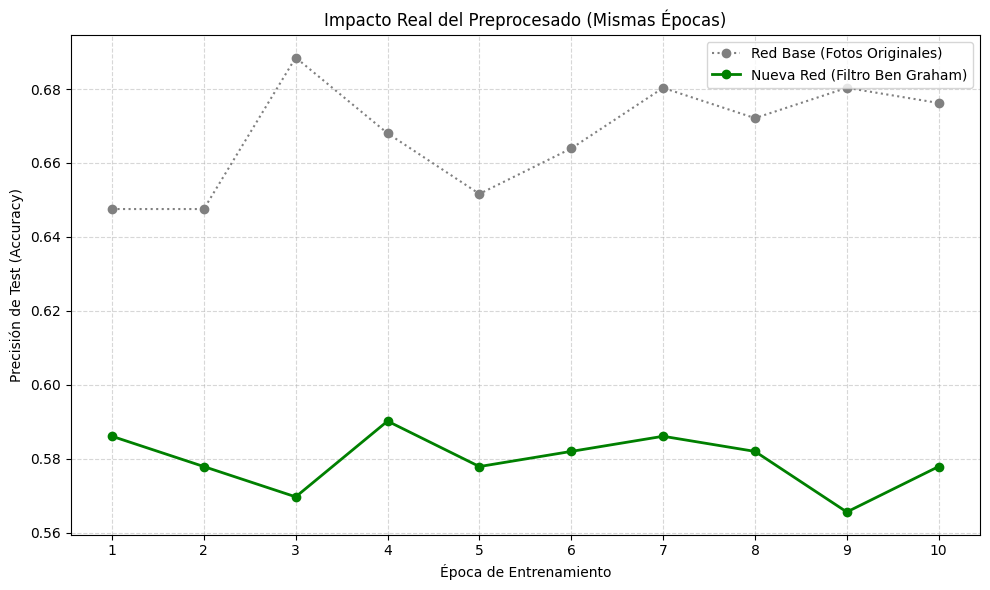

In [43]:
# 5. Generamos la gráfica comparativa final del impacto
plt.figure(figsize=(10, 6))

# Trazamos la línea del historial previo guardado de "EfficientNet-B0" sin filtros
plt.plot(range(1, EPOCAS_PRUEBA + 1), historial_eff, marker='o', linestyle=':', color='gray', label='Red Base (Fotos Originales)')

# Trazamos el historial nuevo superpuesto
plt.plot(range(1, EPOCAS_PRUEBA + 1), historial_eff_proc, marker='o', color='green', linewidth=2, label='Nueva Red (Filtro Ben Graham)')

# Decoración visual
plt.title("Impacto Real del Preprocesado (Mismas Épocas)")
plt.xlabel("Época de Entrenamiento")
plt.ylabel("Precisión de Test (Accuracy)")
plt.xticks(range(1, EPOCAS_PRUEBA + 1))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 5. FASE 3: Clasificador Multiclase de Degeneración (Puesta a Punto y Optimización)

Vamos a implementar nuestro modelo ganador (**EfficientNet-B0**) utilizando el nuevo *dataset* de imágenes preprocesadas (`fotos_procesadas`). 

El objetivo ha cambiado: ya no buscamos predecir simplemente si un paciente está enfermo o sano (entrenamiento binario/demostración), sino catalogar de forma precisa y quirúrgica su progreso de ceguera en los **5 niveles definidos**: 
*   **0:** Sin RD (Retinopatía Diabética)
*   **1:** Leve
*   **2:** Moderada
*   **3:** Grave
*   **4:** Proliferativa.

### 5.1 Carga del Nuevo Dataset y Data Augmentation Dinámico (Las Rotaciones)

In [ ]:
# ==========================================
# 1. Configuración de hiperparámetros - Fase 3
# ==========================================
NUM_CLASES_MULTI = 5
EPOCAS_MULTI = 10
PACIENCIA_EARLY_STOP_MULTI = 10
PACIENCIA_SCHEDULER_MULTI = 4

# ==========================================
# 2. Data Augmentation (Rotaciones y volteos)
# ==========================================
# Solo lo usamos en entrenamiento para más variedad visual
transformaciones_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5), # 50% de probabilidad de volteo espejo
    transforms.RandomRotation(degrees=15),  # Rotación aleatoria +-15 grados
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN_RGB, std=STD_RGB)
])

# En test, aplicamos los pasos estándar (sin giros)
transformaciones_test_multi = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN_RGB, std=STD_RGB)
])

### 5.1.1 Inspección y Carga del Dataset (Asegurando las 5 Categorías)
Primero revisamos las carpetas en el disco duro para verificar que PyTorch las lee como 5 clases independientes. Aprovechamos para ver cómo de balanceadas están las clases (si tenemos muchas fotos de Sanos y pocas de Graves).

In [36]:
# ==========================================
# 3. Cargas de los 5 Directorios (fotos_procesadas)
# ==========================================
CARPETA_MULTI = r"fotos_procesadas"
dataset_multi = datasets.ImageFolder(root=CARPETA_MULTI)

print("="*60)
print(f"[INFO] Análisis del Dataset Original en disco:")
print(f"Total de imágenes detectadas: {len(dataset_multi)}")
print("="*60)

# Comprobamos las clases que ha interpretado PyTorch
print(f"Categorías reconocidas: {dataset_multi.classes}")
print(f"Mapeo interno (Etiqueta -> Índice): {dataset_multi.class_to_idx}\n")

# Contamos cuántas imágenes hay de cada clase
conteo_clases = {nombre: 0 for nombre in dataset_multi.classes}
for _, clase_idx in dataset_multi.samples:
    nombre_clase = dataset_multi.classes[clase_idx]
    conteo_clases[nombre_clase] += 1

print("[INFO] Distribución de imágenes por nivel de retinopatía:")
for nombre, cantidad in conteo_clases.items():
    print(f"   > {nombre}: {cantidad} imágenes")
print("="*60)

[INFO] Análisis del Dataset Original en disco:
Total de imágenes detectadas: 1216
Categorías reconocidas: ['0-noDR', '1-mild', '2-moderate', '3-severe', '4-proliferativeDR']
Mapeo interno (Etiqueta -> Índice): {'0-noDR': 0, '1-mild': 1, '2-moderate': 2, '3-severe': 3, '4-proliferativeDR': 4}

[INFO] Distribución de imágenes por nivel de retinopatía:
   > 0-noDR: 467 imágenes
   > 1-mild: 213 imágenes
   > 2-moderate: 354 imágenes
   > 3-severe: 95 imágenes
   > 4-proliferativeDR: 87 imágenes


### 5.1.2 Partición y Asignación de Transformaciones (Data Augmentation)
Ahora que verificamos que todo esta bien, dividimos aleatoriamente en 80% Entrenamiento y 20% Examen. Aislamos los giros y volteos solo al subconjunto de Entrenamiento.

In [ ]:
# División 80% Train, 20% Test
total_multi = len(dataset_multi)
tamaño_train_multi = int(0.8 * total_multi)
tamaño_test_multi = total_multi - tamaño_train_multi

dataset_train_multi, dataset_test_multi = random_split(
    dataset_multi, 
    [tamaño_train_multi, tamaño_test_multi], 
    generator=torch.Generator().manual_seed(42)
)

# Creamos la clase intermediaria para aislar transformaciones sin mezclar
class DatasetConTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

# Aislamos las transformaciones. ¡Solo Train recibe Augmented (Rotaciones y Volteos)!
dataset_train_multi_aug = DatasetConTransform(dataset_train_multi, transformaciones_aug)
dataset_test_multi_st = DatasetConTransform(dataset_test_multi, transformaciones_test_multi)

# Creamos los Loaders
loader_train_multi = DataLoader(dataset_train_multi_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
loader_test_multi = DataLoader(dataset_test_multi_st, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("[INFO] Partición Completada y verificada:")
print(f"       - Subconjunto Train : {tamaño_train_multi} fotos (con Data Augmentation activado para aprender)")
print(f"       - Subconjunto Test  : {tamaño_test_multi} fotos (en formato limpio original para el examen)")

[INFO] Partición Completada y verificada:
       - Subconjunto Train : 972 fotos (con Data Augmentation activado para aprender)
       - Subconjunto Test  : 244 fotos (en formato limpio original para el examen)


### 5.2. Instanciación del Modelo Multiclase (EfficientNet-B0 para 5 clases)

Repetimos el proceso que nos dió buenos resultados en la Fase 2, pero esta vez configuramos el clasificador de red `EfficientNet-B0` para que el tamaño de su salida sea el de nuestras 5 sub-categorías de retinopatía diabética.
Una vez ensamblado de nuevo, programamos el Optimizador y el _Learning Rate Scheduler_.

In [ ]:
# ==========================================
# 1. Cargamos una versión en blanco del modelo
# ==========================================
modelo_multi = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# 2. Congelamos las capas de aprendizaje (Feature extractors)
for parametro in modelo_multi.parameters():
    parametro.requires_grad = False

# 3. Sustituimos exclusivamente la capa [1] del clasificador lineal (Ahora con NUM_CLASES_MULTI = 5)
neuronas_entrada = modelo_multi.classifier[1].in_features
modelo_multi.classifier[1] = nn.Linear(neuronas_entrada, NUM_CLASES_MULTI) # type: ignore

# 4. Lo volcamos a la memoria de la Unidad de Procesamiento
modelo_multi = modelo_multi.to(device)

# ==========================================
# 5. Configuración de sus herramientas de aprendizaje
# ==========================================
optimizador_multi = optim.Adam(modelo_multi.classifier[1].parameters(), lr=LEARNING_RATE)

# Asignamos el scheduler para intervenir si nuestro clasificador se atasca en la generalización de las 5 categorías
scheduler_multi = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador_multi, 
    mode='min', 
    factor=0.1, 
    patience=PACIENCIA_SCHEDULER_MULTI, 
    min_lr=1e-6
)

print( "[STATUS] Creado nuevo EfficientNet-B0")
print(f"         > Clases a distinguir asignadas: {NUM_CLASES_MULTI}")
print(f"         > Learning Rate Base: {LEARNING_RATE}")
print(f"         > Scheduler OnPlateau Activo. (Paciencia={PACIENCIA_SCHEDULER_MULTI})")

[STATUS] Creado nuevo EfficientNet-B0
         > Clases a distinguir asignadas: 5
         > Learning Rate Base: 0.001
         > Scheduler OnPlateau Activo. (Paciencia=4)


### 5.3 Entrenamiento Multiclase Final

Le pasamos a nuestra función de entrenamiento todos los parámetros que hemos declarado para esta Fase 3. 
Recordemos que ya tenemos la función `entrenar_modelo` que habíamos dejado refactorizada, por lo que solamente tenemos que invocarla con el nuevo `modelo_multi` y los *DataLoaders* con las rotaciones de las imágenes.

In [39]:
print("\n" + "=" * 70)
print(f"   [INICIO] ENTRENAMIENTO MULTICLASE AVANZADO ({NUM_CLASES_MULTI} CLASES)")
print("=" * 70 + "\n")

modelo_multi_entrenado, historial_multi = entrenar_modelo(
    modelo = modelo_multi, 
    loader_train = loader_train_multi, 
    loader_test = loader_test_multi, 
    criterion = criterio_error, 
    optimizer = optimizador_multi, 
    num_epocas = EPOCAS_MULTI,
    scheduler = scheduler_multi,
    patience = PACIENCIA_EARLY_STOP_MULTI
)


   [INICIO] ENTRENAMIENTO MULTICLASE AVANZADO (5 CLASES)

[INFO] Iniciando etapa de pruebas, evaluando comportamiento por 10 épocas...

[INFO] ÉPOCA 1 de 10
[TRAIN] Procesando 16 lotes de imágenes...
   [>] Lote 5/16 (64 fotos) | Error actual en entrenamiento: 1.5187
   [>] Lote 10/16 (64 fotos) | Error actual en entrenamiento: 1.4020
   [>] Lote 15/16 (64 fotos) | Error actual en entrenamiento: 1.2531
   [>] Lote 16/16 (12 fotos) | Error actual en entrenamiento: 1.3961
   [RESULTADO TRAIN] Precisión: 0.3580 | Error medio de aprendizaje: 1.4517

[TEST] Comprobando los conocimientos sobre el conjunto de pruebas...
   [>] Evaluando lote 4/4 (52 fotos)...
   [RESULTADO TEST] Precisión lograda: 0.4016 | Error general en pruebas: 1.4014
   [SCHEDULER] Learning Rate para la próxima época: 0.001000
   [OK] Nuevo mejor modelo encontrado (Loss reducido). Guardando pesos de seguridad.
[INFO] Tiempo de la época 1: 162 segundos.

[INFO] ÉPOCA 2 de 10
[TRAIN] Procesando 16 lotes de imágenes...
   

## 6. FASE 4: Resultados Finales y Evaluación Médica

A diferencia de la Fase 1 donde solo buscábamos iterar sobre un pequeño grupo de prueba para decidir la arquitectura de la red, en esta Fase 4 deberemos desplegar y mostrar:
1.  **Matrices de Confusión Multiclase:** Para ver si la red tiende a confundir una RD "Leve" con una "Moderada", por ejemplo.
2.  **Métricas Clave:** Reales y ponderadas (F1-Score, Precisión y Recall por clase), ya que el número de imágenes en cada etapa visual suele ser desbalanceado.